### Random Forest Algorithm using Tensorflow

##### Απαραίτητες Βιβλιοθήκες

In [2]:
import tensorflow_decision_forests as tfdf

import numpy as np
import pandas as pd
import tensorflow as tf
import tf_keras
import math

# Check the version of TensorFlow Decision Forests
print("Found TensorFlow Decision Forests v" + tfdf.__version__)

2024-02-20 01:03:33.947732: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-20 01:03:33.947780: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-20 01:03:33.949375: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-02-20 01:03:33.956220: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-02-20 01:03:34.831691: W tensorflow/compiler/tf2

Found TensorFlow Decision Forests v1.8.1


##### Διάβασμα dataset και Δημιουργία Dataframe

In [3]:
path_train = "/home/sarantis/Documents/Διπλωματική Εργασία/Diploma-Thesis/PV_dataset/train data.csv"  
train_data = pd.read_csv(path_train, delimiter=';')

path_test = "/home/sarantis/Documents/Διπλωματική Εργασία/Diploma-Thesis/PV_dataset/test data.csv"  
test_data = pd.read_csv(path_test, delimiter=';')

label_column = "class" 

tf_train_dataset = tfdf.keras.pd_dataframe_to_tf_dataset(train_data, label=label_column)
tf_test_dataset = tfdf.keras.pd_dataframe_to_tf_dataset(test_data, label=label_column)

2024-02-20 01:03:36.502971: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-20 01:03:36.556790: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-20 01:03:36.559841: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

L355
2024-02-20 01:03:36.568580: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-20 01:03:36.572438: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-20 01:03:36.726081: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#

##### Train το Μοντέλο

In [25]:
model_rf = tfdf.keras.RandomForestModel(verbose=0)
model_rf.fit(tf_train_dataset)

[INFO 24-02-20 01:30:43.8958 EET kernel.cc:1233] Loading model from path /tmp/tmpqd6m9hrj/model/ with prefix 84b1d61f89224b4c
[INFO 24-02-20 01:30:43.9108 EET decision_forest.cc:660] Model loaded with 300 root(s), 7624 node(s), and 30 input feature(s).
[INFO 24-02-20 01:30:43.9108 EET abstract_model.cc:1344] Engine "RandomForestGeneric" built
[INFO 24-02-20 01:30:43.9108 EET kernel.cc:1061] Use fast generic engine


In [31]:
#model_rf.summary()

inspector = model_rf.make_inspector()
importances = inspector.variable_importances()

print("Variable Importances:")
for variable, importance in importances.items():
    print(f"{variable}: {importance}")

Variable Importances:
INV_MEAN_MIN_DEPTH: [("range_3" (1; #29), 0.2906421428065502), ("range_2" (1; #28), 0.26190346385072244), ("range_4" (1; #30), 0.25426609720873733), ("range_1" (1; #27), 0.2521360519278209), ("I1MIN" (1; #2), 0.22073932625632628), ("I2VAR" (1; #7), 0.21950819807534638), ("I1VAR" (1; #3), 0.2085086241303701), ("I1" (1; #0), 0.2081324478067766), ("I2MIN" (1; #6), 0.20377696970381096), ("I3var" (1; #11), 0.20255967223249602), ("I2" (1; #4), 0.19982764833946892), ("Vdcmax1" (1; #23), 0.1924512777226497), ("I4" (1; #12), 0.19214231024097655), ("I3" (1; #8), 0.19195454834826703), ("I4MIN" (1; #14), 0.19033387315208058), ("Vdcmin1" (1; #25), 0.19000145442967104), ("T" (1; #22), 0.18949863094330707), ("I3max" (1; #9), 0.18940447002822045), ("Pdcmean1" (1; #21), 0.1893139156719629), ("Vdcmean1" (1; #24), 0.18901139677375323), ("Itotalmax1" (1; #19), 0.1887890651518098), ("I2MAX" (1; #5), 0.18877308380979507), ("I6" (1; #16), 0.18866701972265001), ("Itotalmin1" (1; #20), 0.

##### Αξιολόγηση Μοντέλου

In [43]:
model_rf.compile(metrics=["accuracy"]) 
evaluation = model_rf.evaluate(tf_test_dataset, return_dict=True)
print()

for name, value in evaluation.items():
  print(f"{name}: {value:.4f}")


1/1 [==============================] - 0s 120ms/step - loss: 0.0000e+00 - accuracy: 0.9100

loss: 0.0000
accuracy: 0.9100


##### Self-Evaluation

In [32]:
model_rf.make_inspector().evaluation()

Evaluation(num_examples=600, accuracy=1.0, loss=0.03632503500363479, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

#### Plot το Μοντέλο

In [35]:
model_rf.make_inspector().training_logs()

[TrainLog(num_trees=1, evaluation=Evaluation(num_examples=224, accuracy=0.9910714285714286, loss=0.32181831768580843, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)),
 TrainLog(num_trees=11, evaluation=Evaluation(num_examples=595, accuracy=0.9932773109243698, loss=0.1597213840785147, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)),
 TrainLog(num_trees=21, evaluation=Evaluation(num_examples=600, accuracy=0.9983333333333333, loss=0.0513456708441178, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)),
 TrainLog(num_trees=31, evaluation=Evaluation(num_examples=600, accuracy=1.0, loss=0.045617721950014435, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)),
 TrainLog(num_trees=41, evaluation=Evaluation(num_examples=600, accuracy=1.0, loss=0.04230948535725474, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)),
 TrainLog(num_trees=51, evaluation=Evaluation(num_examples=600, accuracy=1.0, loss=0.03900769098351399, rmse=None, ndcg=None, aucs=None, auuc=None, qini

1/1 [==============================] - 0s 80ms/step - loss: 0.0000e+00 - accuracy: 0.9100


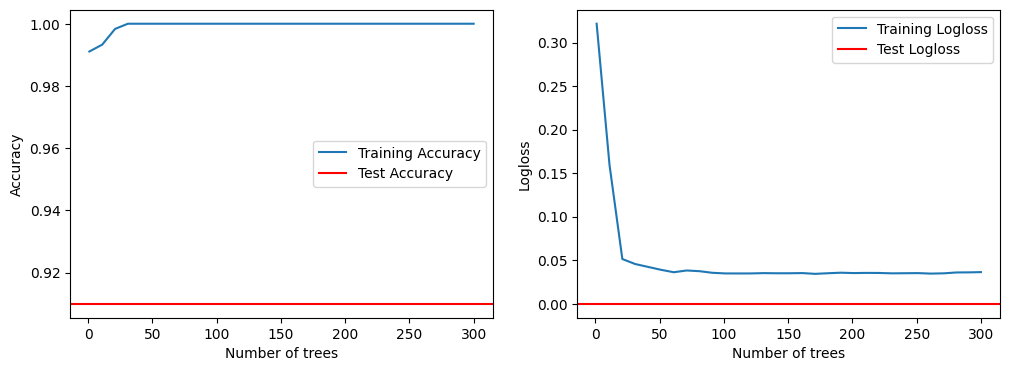

In [46]:
import matplotlib.pyplot as plt

train_logs = model_rf.make_inspector().training_logs()
evaluation = model_rf.evaluate(tf_test_dataset, return_dict=True)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in train_logs], [log.evaluation.accuracy for log in train_logs], label='Training Accuracy')
plt.axhline(evaluation['accuracy'], color='red', linestyle='-', label='Test Accuracy')
plt.xlabel("Number of trees")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in train_logs], [log.evaluation.loss for log in train_logs], label='Training Logloss')
plt.axhline(evaluation['loss'], color='red', linestyle='-', label='Test Logloss')
plt.xlabel("Number of trees")
plt.ylabel("Logloss")
plt.legend()

plt.show()